# Identification de la diffusivité thermique par éléments finis 1D

Ce notebook a pour objectif d'identifier une diffusivité thermique effective `alpha` à partir de mesures expérimentales de température. On considère deux capteurs, `T1` et `T2`, séparés par une distance connue `L_ice`.

Le modèle numérique est un modèle transitoire unidimensionnel de diffusion thermique. La température `T2(t)` est imposée comme condition de Dirichlet au bord froid, tandis que la température `T1(t)` est calculée par le modèle FEM au bord opposé puis comparée à la mesure expérimentale.

L'identification de `alpha` est faite en comparant la pente globale de refroidissement de `T1_FEM` avec celle de `T1_exp` sur une fenêtre temporelle choisie. Une étude de convergence en maillage est ensuite réalisée afin de vérifier l'influence du nombre de noeuds sur la valeur identifiée.

## Bloc 1 — Imports et paramètres globaux

Ce bloc initialise les bibliothèques nécessaires et définit les paramètres principaux du problème.

La distance `L_ice` correspond à la distance physique entre les deux capteurs de température `T1` et `T2`. Cette distance définit la longueur du domaine 1D utilisé dans le modèle éléments finis.

Les paramètres `fit_start_fraction_no_ice` et `fit_start_fraction_ice` permettent de sélectionner la partie droite des courbes expérimentales pour calculer les pentes. Par exemple, une valeur de `0.5` signifie que seule la seconde moitié de la courbe est utilisée.

Le domaine de recherche de la diffusivité thermique `alpha` est défini entre `alpha_min` et `alpha_max`. Les valeurs testées sont générées avec une échelle logarithmique, ce qui permet d'explorer efficacement plusieurs ordres de grandeur.

Enfin, une valeur de référence de la diffusivité thermique de l'acier est calculée à partir de :

$$
\alpha_{\mathrm{acier}} = \frac{\lambda}{\rho c_p}
$$

Cette valeur sert uniquement de comparaison bibliographique.

In [352]:
# ============================================================
# BLOQUE 1
# IMPORTS ET PARAMÈTRES GLOBAUX
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

from google.colab import files


# ------------------------------------------------------------
# Distance entre les deux capteurs T1 et T2
# ------------------------------------------------------------

L_ice = 72.8e-3   # [m]


# ------------------------------------------------------------
# Fenêtres utilisées pour calculer les pentes
# ------------------------------------------------------------
# 0.5 signifie : on utilise la moitié droite de la courbe.

fit_start_fraction_no_ice = 0.5
fit_start_fraction_ice = 0.5


# ------------------------------------------------------------
# Domaine de recherche de alpha
# ------------------------------------------------------------

alpha_min = 1e-9
alpha_max = 1e-6
n_alpha = 1000

alpha_values = np.logspace(
    np.log10(alpha_min),
    np.log10(alpha_max),
    n_alpha
)


# ------------------------------------------------------------
# Valeurs de référence pour un acier classique
# ------------------------------------------------------------

rho_steel = 2279        # [kg/m3] Toca normalizarlo por cada échantillon
cp_steel = 800          # [J/(kg K)] De cada mineral
lambda_steel = 0.5       # [W/(m K)]

alpha_steel_ref = lambda_steel / (rho_steel * cp_steel)


print("Paramètres globaux chargés.")
print(f"L_ice = {L_ice:.6e} m")
print(f"alpha_min = {alpha_min:.6e} m²/s")
print(f"alpha_max = {alpha_max:.6e} m²/s")
print(f"n_alpha = {n_alpha}")
print(f"alpha_steel_ref = {alpha_steel_ref:.6e} m²/s")

Paramètres globaux chargés.
L_ice = 7.280000e-02 m
alpha_min = 1.000000e-09 m²/s
alpha_max = 1.000000e-06 m²/s
n_alpha = 1000
alpha_steel_ref = 2.742431e-07 m²/s


## Bloc 2 — Lecture des fichiers expérimentaux

Ce bloc définit une fonction de lecture des fichiers expérimentaux au format texte. Les fichiers sont supposés contenir les colonnes suivantes :

- date ;
- heure ;
- temps en secondes ;
- température `T1` ;
- température `T2`.

La fonction est compatible avec les notations décimales françaises et anglaises, c'est-à-dire avec des virgules ou des points comme séparateurs décimaux.

Après la lecture, les colonnes numériques sont nettoyées, converties en valeurs flottantes, puis les lignes invalides sont supprimées. La fonction retourne finalement un `DataFrame` contenant les données expérimentales ainsi que le nom du fichier chargé.

In [353]:
# ============================================================
# BLOQUE 2
# LECTURE DES FICHIERS TXT EXPÉRIMENTAUX
# ============================================================

def load_experimental_txt():
    """
    Charge un fichier txt expérimental avec les colonnes :
    Date, Heure, Temps (s), T1, T2.

    Compatible avec :
    - décimales avec virgule : 94,268
    - décimales avec point   : 94.268
    """

    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

    df = pd.read_csv(
        io.BytesIO(uploaded[file_name]),
        sep=r"\s+",
        engine="python",
        skiprows=1,
        names=["Date", "Heure", "Temps_s", "T1", "T2"]
    )

    for col in ["Temps_s", "T1", "T2"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )

        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(
        subset=["Temps_s", "T1", "T2"]
    ).reset_index(drop=True)

    if len(df) == 0:
        raise ValueError(
            "Le fichier a été lu, mais aucune donnée numérique valide n'a été trouvée."
        )

    print("Fichier chargé :")
    print(file_name)
    print(f"Nombre de points lus = {len(df)}")

    display(df.head())
    display(df.tail())

    return df, file_name

## Bloc 3 — Fonctions utilitaires : pentes, fonctions de forme et quadrature

Ce bloc regroupe plusieurs outils utilisés ensuite par le modèle numérique.

La fonction `extract_right_part` permet d'extraire une fenêtre temporelle située dans la partie droite d'une courbe. Elle est utilisée pour éviter d'identifier les paramètres à partir de la phase transitoire initiale, qui peut être fortement influencée par les conditions expérimentales de départ.

La fonction `linear_slope` calcule la pente d'une courbe par régression linéaire. Elle ajuste une droite de la forme :

$$
T(t) = a_0 + a_1 t
$$

et retourne la pente `a1`.

La fonction `lagrange_p1` définit les fonctions de forme linéaires P1 sur l'élément de référence $[-1,1]$ :

$$
N_1(\xi) = \frac{1-\xi}{2}
$$

$$
N_2(\xi) = \frac{1+\xi}{2}
$$

Enfin, les points et poids de Gauss sont définis pour effectuer une quadrature de Gauss-Legendre à deux points lors de l'assemblage des matrices élémentaires.

In [354]:
# ============================================================
# BLOQUE 3
# OUTILS POUR LES PENTES, FONCTIONS DE FORME ET QUADRATURE
# ============================================================


# ------------------------------------------------------------
# Extraction de la partie droite d'une courbe
# ------------------------------------------------------------

def extract_right_part(t, y, start_fraction=0.5):
    """
    Extrait la partie droite d'une courbe.

    Exemple :
    start_fraction = 0.5 signifie que l'on garde la moitié droite.
    """

    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    t_start = t[0] + start_fraction * (t[-1] - t[0])

    mask = t >= t_start

    if np.sum(mask) < 2:
        raise ValueError(
            "Pas assez de points dans la fenêtre choisie pour calculer une pente."
        )

    return t[mask], y[mask], mask


# ------------------------------------------------------------
# Calcul de pente par ajustement linéaire
# ------------------------------------------------------------

def linear_slope(t, y, start_fraction=0.5):
    """
    Calcule la pente d'un ajustement linéaire :

        y = b0 + b1 t

    L'ajustement est fait uniquement sur la partie droite de la courbe.
    """

    t_fit, y_fit, mask = extract_right_part(
        t,
        y,
        start_fraction=start_fraction
    )

    b1, b0 = np.polyfit(
        t_fit,
        y_fit,
        deg=1
    )

    return b1


# ------------------------------------------------------------
# Fonctions de forme P1 sur l'élément de référence [-1, 1]
# ------------------------------------------------------------

def lagrange_p1(xi):
    """
    Fonctions de forme linéaires P1.

    N1(xi) = (1 - xi) / 2
    N2(xi) = (1 + xi) / 2
    """

    N = np.array([
        0.5 * (1.0 - xi),
        0.5 * (1.0 + xi)
    ])

    dN_dxi = np.array([
        -0.5,
         0.5
    ])

    return N, dN_dxi


# ------------------------------------------------------------
# Quadrature de Gauss-Legendre à 2 points
# ------------------------------------------------------------

gauss_points = np.array([
    -1.0 / np.sqrt(3.0),
     1.0 / np.sqrt(3.0)
])

gauss_weights = np.array([
    1.0,
    1.0
])


print("Fonctions de pente, fonctions de forme et quadrature définies.")

Fonctions de pente, fonctions de forme et quadrature définies.


## Bloc 4 — Assemblage éléments finis 1D P1

Ce bloc construit les matrices globales du problème éléments finis 1D avec des éléments linéaires P1.

Le modèle résolu est une équation de diffusion thermique transitoire avec un terme de perte diffus :

$$
\frac{\partial T}{\partial t}
=
\alpha \frac{\partial^2 T}{\partial x^2}
-
s_{\mathrm{loss}}
$$

Après discrétisation spatiale par éléments finis, cette équation prend la forme semi-discrète :

$$
M \frac{dT}{dt} + \alpha K T = F
$$

où :

- `M` est la matrice de masse ;
- `K` est la matrice de rigidité thermique ;
- `F` contient le terme source associé aux pertes thermiques ;
- `alpha` est la diffusivité thermique à identifier.

L'assemblage est réalisé élément par élément. Pour chaque élément, les contributions locales `M_e`, `K_e` et `F_e` sont calculées par quadrature de Gauss, puis ajoutées dans les matrices globales.

In [355]:
# ============================================================
# BLOQUE 4
# ASSEMBLAGE FEM 1D P1
# ============================================================

def assemble_fem_1d_p1(x_nodes, s_loss):
    """
    Assemble les matrices globales M, K et F pour un maillage 1D P1.

    Équation transitoire :

        dT/dt = alpha d²T/dx² - s_loss

    Forme semi-discrète :

        M dT/dt + alpha K T = F
    """

    x_nodes = np.asarray(x_nodes, dtype=float)

    n_nodes = len(x_nodes)
    n_elements = n_nodes - 1

    M = np.zeros((n_nodes, n_nodes))
    K = np.zeros((n_nodes, n_nodes))
    F = np.zeros(n_nodes)

    for e in range(n_elements):

        x_left = x_nodes[e]
        x_right = x_nodes[e + 1]

        h_e = x_right - x_left
        J = h_e / 2.0

        local_nodes = [e, e + 1]

        M_e = np.zeros((2, 2))
        K_e = np.zeros((2, 2))
        F_e = np.zeros(2)

        for xi, w in zip(gauss_points, gauss_weights):

            N, dN_dxi = lagrange_p1(xi)

            dN_dx = dN_dxi / J

            M_e += w * np.outer(N, N) * J
            K_e += w * np.outer(dN_dx, dN_dx) * J
            F_e += w * (-s_loss * N) * J

        for i_local in range(2):

            i_global = local_nodes[i_local]

            F[i_global] += F_e[i_local]

            for j_local in range(2):

                j_global = local_nodes[j_local]

                M[i_global, j_global] += M_e[i_local, j_local]
                K[i_global, j_global] += K_e[i_local, j_local]

    return M, K, F


print("Fonction d'assemblage FEM définie.")

Fonction d'assemblage FEM définie.


## Bloc 5 — Simulation FEM transitoire pour une valeur donnée de alpha

Ce bloc définit la fonction principale de simulation thermique pour une valeur donnée de la diffusivité `alpha`.

Le domaine spatial est défini entre les deux capteurs :

$$
x = 0 \quad \rightarrow \quad T1_{\mathrm{FEM}}(t)
$$

$$
x = L \quad \rightarrow \quad T2_{\mathrm{exp}}(t)
$$

La température `T2(t)` est imposée comme condition de Dirichlet au dernier noeud du maillage. Les autres noeuds sont des inconnues du système FEM.

La fonction sépare donc les noeuds en deux groupes :

- `free_nodes` : noeuds libres, dont la température est calculée ;
- `dirichlet_nodes` : noeud imposé, où la température est égale à `T2_bc(t)`.

La condition initiale est imposée sous forme d'un profil linéaire entre les deux températures mesurées au début de la fenêtre :

$$
T(x,0)
=
T1(0)
+
\left(T2(0)-T1(0)\right)\frac{x}{L}
$$

Cette correction est essentielle. Une initialisation uniforme à `T1(0)` sur tous les noeuds libres créerait un domaine artificiellement trop chaud, surtout lorsque le maillage est raffiné.

Le schéma temporel utilisé est implicite. À chaque pas de temps, on résout un système linéaire pour obtenir les températures aux noeuds libres à l'instant suivant.

### Remarque importante sur la condition initiale

La condition initiale du champ de température doit être compatible avec les deux mesures initiales `T1(0)` et `T2(0)`.

Une erreur possible consiste à initialiser tous les noeuds libres avec `T1(0)` puis à imposer uniquement le dernier noeud à `T2(0)`. Dans ce cas, pour un maillage fin, presque tout le domaine commence artificiellement à la température chaude `T1(0)`, tandis que seul le dernier noeud est froid. Cette situation introduit une réserve thermique non physique dans le modèle.

La condition initiale utilisée ici est donc un profil linéaire entre les deux mesures initiales. Cela permet de respecter simultanément :

$$
T(0,0) = T1_{\mathrm{exp}}(0)
$$

$$
T(L,0) = T2_{\mathrm{exp}}(0)
$$

Cette correction améliore fortement la cohérence du modèle lorsque le maillage est raffiné.

In [356]:
# ============================================================
# BLOQUE 5
# SIMULATION FEM TRANSITOIRE POUR UN ALPHA DONNÉ
# CONDITION INITIALE CORRIGÉE
# ============================================================

def simulate_T1_for_alpha_mesh(
    alpha,
    tau,
    T1_exp,
    T2_bc,
    x_nodes,
    M,
    K,
    F,
    times_to_save=None,
    initial_condition="linear"
):
    """
    Simule T1_FEM pour une valeur donnée de alpha.

    Domaine :
        x = 0  -> T1_FEM calculé
        x = L  -> T2 expérimental imposé

    Condition aux limites :
        T(L,t) = T2_exp(t)

    Condition initiale recommandée :
        profil linéaire entre T1_exp(0) et T2_exp(0)

    Cela évite l'erreur non physique :
        T(x,0) = T1_exp(0) partout sauf au dernier noeud.
    """

    alpha = float(alpha)

    tau = np.asarray(tau, dtype=float)
    T1_exp = np.asarray(T1_exp, dtype=float)
    T2_bc = np.asarray(T2_bc, dtype=float)
    x_nodes = np.asarray(x_nodes, dtype=float)

    n_nodes = len(x_nodes)

    if len(tau) != len(T1_exp):
        raise ValueError("tau et T1_exp doivent avoir la même taille.")

    if len(tau) != len(T2_bc):
        raise ValueError("tau et T2_bc doivent avoir la même taille.")

    # Dernier noeud imposé : T2 expérimental
    dirichlet_nodes = np.array([n_nodes - 1], dtype=int)

    # Tous les autres noeuds sont libres
    free_nodes = np.arange(n_nodes - 1)

    M_ff = M[np.ix_(free_nodes, free_nodes)]
    M_fd = M[np.ix_(free_nodes, dirichlet_nodes)]

    K_ff = K[np.ix_(free_nodes, free_nodes)]
    K_fd = K[np.ix_(free_nodes, dirichlet_nodes)]

    F_f = F[free_nodes]

    L_domain = x_nodes[-1] - x_nodes[0]

    if L_domain <= 0:
        raise ValueError("Le domaine spatial doit avoir une longueur positive.")

    # ------------------------------------------------------------
    # Condition initiale
    # ------------------------------------------------------------

    if initial_condition == "linear":

        # Profil initial cohérent avec les deux mesures initiales :
        #
        # T(0,0) = T1_exp[0]
        # T(L,0) = T2_bc[0]

        T_initial_full = (
            T1_exp[0]
            +
            (T2_bc[0] - T1_exp[0])
            *
            (x_nodes - x_nodes[0])
            /
            L_domain
        )

    elif initial_condition == "uniform_T1":

        # Ancienne version, conservée seulement pour comparaison.
        # Non recommandée si T1_exp[0] et T2_bc[0] sont très différents.

        T_initial_full = np.full(
            n_nodes,
            T1_exp[0],
            dtype=float
        )

        T_initial_full[dirichlet_nodes] = T2_bc[0]

    else:
        raise ValueError(
            "initial_condition doit être 'linear' ou 'uniform_T1'."
        )

    # Solution réduite aux noeuds libres
    T_f = T_initial_full[free_nodes].copy()

    T1_fem = np.zeros_like(T1_exp, dtype=float)
    T1_fem[0] = T_initial_full[0]

    saved_profiles = {}

    if times_to_save is None:
        save_indices = []
    else:
        save_indices = [
            int(np.argmin(np.abs(tau - time_value)))
            for time_value in times_to_save
        ]
        save_indices = sorted(set(save_indices))

    def build_full_temperature(T_f_current, T2_current):
        T_full = np.zeros(n_nodes)
        T_full[free_nodes] = T_f_current
        T_full[dirichlet_nodes] = T2_current
        return T_full

    if 0 in save_indices:
        saved_profiles[0] = build_full_temperature(
            T_f,
            T2_bc[0]
        )

    for n in range(len(tau) - 1):

        dt_n = tau[n + 1] - tau[n]

        if dt_n <= 0:
            raise ValueError(
                "Le vecteur tau doit être strictement croissant."
            )

        T_d_n = np.array([T2_bc[n]])
        T_d_np1 = np.array([T2_bc[n + 1]])

        dT_d = (T_d_np1 - T_d_n) / dt_n

        # Schéma implicite :
        #
        # (M_ff/dt + alpha K_ff) T_f^{n+1}
        # =
        # M_ff T_f^n/dt
        # + F_f
        # - M_fd dT_d/dt
        # - alpha K_fd T_d^{n+1}

        A = M_ff / dt_n + alpha * K_ff

        b = (
            M_ff @ T_f / dt_n
            + F_f
            - M_fd @ dT_d
            - alpha * (K_fd @ T_d_np1)
        )

        T_f = np.linalg.solve(A, b)

        T1_fem[n + 1] = T_f[0]

        if (n + 1) in save_indices:
            saved_profiles[n + 1] = build_full_temperature(
                T_f,
                T2_bc[n + 1]
            )

    return T1_fem, saved_profiles


print("Fonction de simulation FEM redéfinie avec condition initiale linéaire.")

Fonction de simulation FEM redéfinie avec condition initiale linéaire.


## Bloc 6 — Première fonction d'identification de alpha

Ce bloc définit une première version de la fonction `identify_alpha_for_n_nodes`. Cette fonction teste plusieurs valeurs de `alpha` pour un maillage donné, simule la courbe `T1_FEM(t)` associée à chaque valeur, puis compare sa pente à celle de la courbe expérimentale `T1_exp(t)`.

Le critère minimisé est l'erreur relative entre les pentes :

$$
\varepsilon_{\mathrm{pente}}
=
\frac{
\left| a_{\mathrm{FEM}} - a_{\mathrm{exp}} \right|
}{
\left| a_{\mathrm{exp}} \right|
}
$$

où `a_exp` est la pente expérimentale et `a_FEM` la pente obtenue numériquement.

Cette première fonction est utile pour comprendre la logique générale de l'identification. Cependant, dans la suite du notebook, elle est redéfinie afin d'utiliser uniquement la fenêtre temporelle d'identification.

In [357]:
# ============================================================
# BLOQUE 6
# IDENTIFICATION DE ALPHA POUR UN NOMBRE DONNÉ DE NŒUDS
# ============================================================

def identify_alpha_for_n_nodes(
    N_nodes,
    times_to_save=None,
    verbose=True
):
    """
    Identifie alpha pour un maillage avec N_nodes.

    Convention :
        x = 0  -> T1_FEM calculé
        x = L  -> T2_exp imposé

    Le critère est l'écart relatif entre les pentes de :
        T1_exp
        T1_FEM

    Les pentes sont calculées sur la partie droite de la courbe.
    """

    if N_nodes < 2:
        raise ValueError("Il faut au moins 2 nœuds.")

    N_elements = N_nodes - 1

    # Maillage uniforme entre T1 et T2
    x_nodes = np.linspace(
        0.0,
        L_ice,
        N_nodes
    )

    # Assemblage FEM
    M, K, F = assemble_fem_1d_p1(
        x_nodes=x_nodes,
        s_loss=s_loss_no_ice
    )

    # Pente expérimentale de T1
    slope_T1_exp = linear_slope(
        tau_ice,
        T1_ice_exp,
        start_fraction=fit_start_fraction_ice
    )

    rows = []

    for alpha_value in alpha_values:

        T1_fem_alpha, _ = simulate_T1_for_alpha_mesh(
            alpha=alpha_value,
            tau=tau_ice,
            T1_exp=T1_ice_exp,
            T2_bc=T2_ice_bc,
            x_nodes=x_nodes,
            M=M,
            K=K,
            F=F,
            times_to_save=None
        )

        slope_T1_fem = linear_slope(
            tau_ice,
            T1_fem_alpha,
            start_fraction=fit_start_fraction_ice
        )

        abs_error = abs(
            slope_T1_fem
            -
            slope_T1_exp
        )

        rel_error = abs_error / max(
            abs(slope_T1_exp),
            1.0e-15
        )

        rows.append({
            "N_nodes": N_nodes,
            "N_elements": N_elements,
            "alpha": alpha_value,
            "slope_T1_exp": slope_T1_exp,
            "slope_T1_fem": slope_T1_fem,
            "abs_slope_error": abs_error,
            "relative_slope_error": rel_error
        })

    df_alpha = pd.DataFrame(rows)

    idx_best = df_alpha["relative_slope_error"].idxmin()

    best_row = df_alpha.loc[idx_best].copy()

    alpha_best = best_row["alpha"]

    # Simulation finale avec le meilleur alpha
    T1_fem_best, saved_profiles = simulate_T1_for_alpha_mesh(
        alpha=alpha_best,
        tau=tau_ice,
        T1_exp=T1_ice_exp,
        T2_bc=T2_ice_bc,
        x_nodes=x_nodes,
        M=M,
        K=K,
        F=F,
        times_to_save=times_to_save
    )

    if alpha_best == alpha_values[0]:
        boundary_status = "lower_bound"
    elif alpha_best == alpha_values[-1]:
        boundary_status = "upper_bound"
    else:
        boundary_status = "inside"

    if verbose:

        print()
        print("Résultat pour le maillage :")
        print(f"N_nodes = {N_nodes}")
        print(f"N_elements = {N_elements}")
        print(f"alpha_best = {alpha_best:.6e} m²/s")
        print(f"pente T1 exp = {best_row['slope_T1_exp']:.6e} °C/s")
        print(f"pente T1 FEM = {best_row['slope_T1_fem']:.6e} °C/s")
        print(f"erreur absolue de pente = {best_row['abs_slope_error']:.6e} °C/s")
        print(f"écart relatif de pente = {100.0 * best_row['relative_slope_error']:.6f} %")
        print(f"position dans l'intervalle alpha = {boundary_status}")

    return {
        "N_nodes": N_nodes,
        "N_elements": N_elements,
        "x_nodes": x_nodes,
        "M": M,
        "K": K,
        "F": F,
        "df_alpha": df_alpha,
        "best_row": best_row,
        "alpha_best": alpha_best,
        "T1_fem_best": T1_fem_best,
        "saved_profiles": saved_profiles,
        "boundary_status": boundary_status
    }


print("Fonction d'identification de alpha définie.")

Fonction d'identification de alpha définie.


## Bloc 7 — Traitement du fichier sans glace et estimation des pertes

Ce bloc charge le fichier expérimental réalisé sans glace. L'objectif de cet essai est d'estimer un terme de perte thermique effective `s_loss_no_ice`.

La partie utile de l'expérience est définie à partir du maximum de `T1`. Le temps est ensuite remis à zéro afin de travailler avec :

$$
\tau = t - t_0
$$

Sur la partie droite de la courbe `T1`, une régression linéaire est effectuée. La pente obtenue représente le taux de refroidissement expérimental sans glace.

Le terme de perte est alors défini par :

$$
s_{\mathrm{loss}} = -\frac{dT1}{dt}
$$

Cette perte est ensuite utilisée dans le modèle FEM comme terme source négatif. Elle représente une approximation globale des pertes thermiques observées en absence de glace.

Charge le fichier SANS glace


Saving 2D_noice_50c.txt to 2D_noice_50c.txt
Fichier chargé :
2D_noice_50c.txt
Nombre de points lus = 287


,Date,Heure,Temps_s,T1,T2
0,13/07/2026,16:36:24,0.288,46.122,41.937
1,13/07/2026,16:36:29,5.289,46.337,42.845
2,13/07/2026,16:36:34,10.289,46.504,43.501
3,13/07/2026,16:36:39,15.290,46.595,43.929
4,13/07/2026,16:36:44,20.290,46.664,44.236


,Date,Heure,Temps_s,T1,T2
282,13/07/2026,16:59:54,1410.425,43.198,42.603
283,13/07/2026,16:59:59,1415.426,43.198,42.606
284,13/07/2026,17:00:04,1420.426,43.198,42.593
285,13/07/2026,17:00:09,1425.426,43.147,42.568
286,13/07/2026,17:00:14,1430.427,43.193,42.599



Résultat sans glace :
Fichier = 2D_noice_50c.txt
t0 = 65.294000 s
T1(t0) = 46.816000 °C
pente dT1/dt = -2.617378e-03 °C/s
s_loss_no_ice = 2.617378e-03 °C/s
Début fenêtre de pente = 685.064000 s


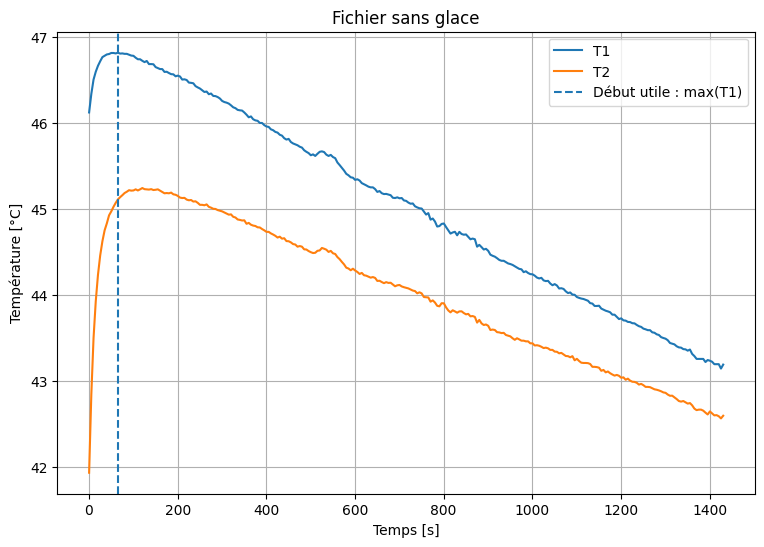

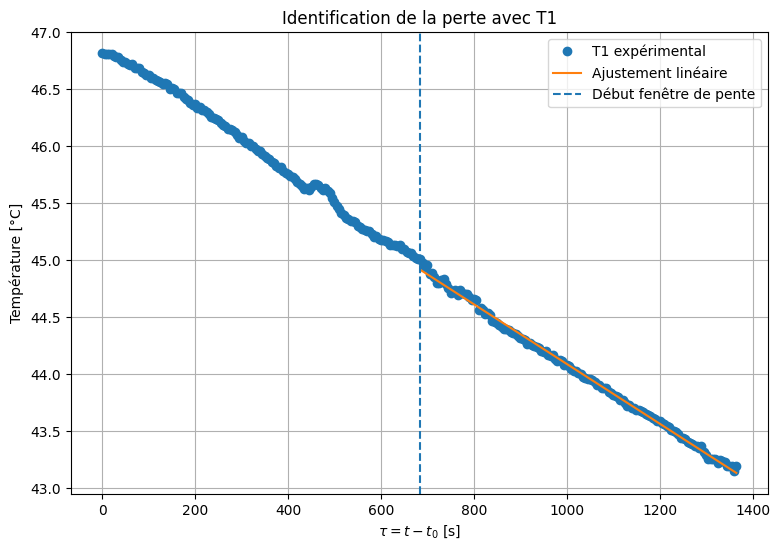

In [358]:
# ============================================================
# BLOQUE 7
# FICHIER SANS GLACE : CALCUL DE LA PERTE s_loss_no_ice
# ============================================================

print("Charge le fichier SANS glace")

df_no_ice, file_no_ice = load_experimental_txt()


# ------------------------------------------------------------
# Extraction des colonnes
# ------------------------------------------------------------

t_no_ice = df_no_ice["Temps_s"].to_numpy(dtype=float)
T1_no_ice = df_no_ice["T1"].to_numpy(dtype=float)
T2_no_ice = df_no_ice["T2"].to_numpy(dtype=float)


# ------------------------------------------------------------
# Début utile : maximum de T1
# ------------------------------------------------------------

idx0_no_ice = int(np.argmax(T1_no_ice))

t0_no_ice = t_no_ice[idx0_no_ice]


# ------------------------------------------------------------
# Données utiles à partir du maximum de T1
# ------------------------------------------------------------

df_no_ice_useful = df_no_ice.iloc[idx0_no_ice:].copy().reset_index(drop=True)

df_no_ice_useful["tau_s"] = (
    df_no_ice_useful["Temps_s"]
    -
    t0_no_ice
)

tau_no_ice = df_no_ice_useful["tau_s"].to_numpy(dtype=float)

T1_no_ice_useful = df_no_ice_useful["T1"].to_numpy(dtype=float)


# ------------------------------------------------------------
# Calcul de la pente de T1 sur la partie droite
# ------------------------------------------------------------

tau_fit_no_ice, T1_fit_no_ice_data, mask_no_ice = extract_right_part(
    tau_no_ice,
    T1_no_ice_useful,
    start_fraction=fit_start_fraction_no_ice
)

a1_no_ice, a0_no_ice = np.polyfit(
    tau_fit_no_ice,
    T1_fit_no_ice_data,
    deg=1
)

T1_fit_no_ice = (
    a0_no_ice
    +
    a1_no_ice * tau_fit_no_ice
)


# ------------------------------------------------------------
# Perte diffuse effective
# ------------------------------------------------------------

s_loss_no_ice = -a1_no_ice


print()
print("Résultat sans glace :")
print(f"Fichier = {file_no_ice}")
print(f"t0 = {t0_no_ice:.6f} s")
print(f"T1(t0) = {T1_no_ice[idx0_no_ice]:.6f} °C")
print(f"pente dT1/dt = {a1_no_ice:.6e} °C/s")
print(f"s_loss_no_ice = {s_loss_no_ice:.6e} °C/s")
print(f"Début fenêtre de pente = {tau_fit_no_ice[0]:.6f} s")


# ------------------------------------------------------------
# Visualisation
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    t_no_ice,
    T1_no_ice,
    label="T1"
)

plt.plot(
    t_no_ice,
    T2_no_ice,
    label="T2"
)

plt.axvline(
    t0_no_ice,
    linestyle="--",
    label="Début utile : max(T1)"
)

plt.xlabel("Temps [s]")
plt.ylabel("Température [°C]")
plt.title("Fichier sans glace")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(9, 6))

plt.plot(
    tau_no_ice,
    T1_no_ice_useful,
    marker="o",
    linestyle="",
    label="T1 expérimental"
)

plt.plot(
    tau_fit_no_ice,
    T1_fit_no_ice,
    label="Ajustement linéaire"
)

plt.axvline(
    tau_fit_no_ice[0],
    linestyle="--",
    label="Début fenêtre de pente"
)

plt.xlabel(r"$\tau = t-t_0$ [s]")
plt.ylabel("Température [°C]")
plt.title("Identification de la perte avec T1")
plt.grid(True)
plt.legend()
plt.show()

## Bloc 8 — Chargement du fichier avec glace

Ce bloc charge le fichier expérimental réalisé avec glace. C'est cet essai qui est utilisé pour identifier la diffusivité thermique effective `alpha`.

Comme pour le cas sans glace, le début utile de l'expérience est pris au maximum de `T1`. Le temps est ensuite remis à zéro.

Dans cette étape :

- `T1_ice_exp` est la température expérimentale que le modèle FEM doit reproduire ;
- `T2_ice_bc` est la température imposée au bord froid du domaine ;
- `tau_ice` est le temps relatif utilisé pour la simulation.

La température `T2` n'est donc pas ajustée par le modèle. Elle est directement utilisée comme condition de Dirichlet variable dans le temps.

Charge le fichier AVEC glace


Saving 2D_ice_50c.txt to 2D_ice_50c.txt
Fichier chargé :
2D_ice_50c.txt
Nombre de points lus = 243


,Date,Heure,Temps_s,T1,T2
0,10/07/2026,15:05:37,0.288,54.761,8.206
1,10/07/2026,15:05:42,5.287,54.731,5.422
2,10/07/2026,15:05:47,10.288,54.600,5.029
3,10/07/2026,15:05:52,15.288,54.581,4.005
4,10/07/2026,15:05:57,20.289,54.556,3.518


,Date,Heure,Temps_s,T1,T2
238,10/07/2026,15:25:27,1190.410,43.057,3.117
239,10/07/2026,15:25:32,1195.411,43.004,3.103
240,10/07/2026,15:25:37,1200.411,42.976,3.100
241,10/07/2026,15:25:42,1205.412,42.931,3.086
242,10/07/2026,15:25:47,1210.412,42.872,3.075



Résultat avec glace :
Fichier = 2D_ice_50c.txt
t0 = 0.288000 s
T1(t0) = 54.761000 °C
T2(t0) = 8.206000 °C
Durée utile = 1210.124000 s
Nombre de points utiles = 243


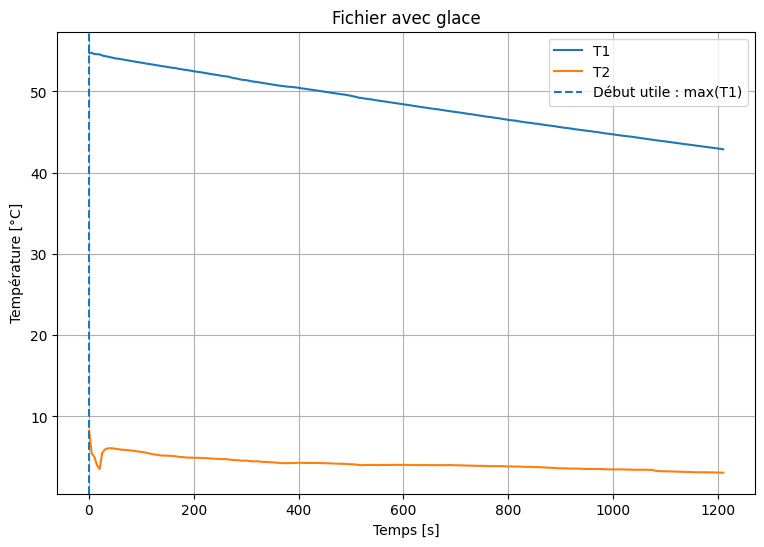

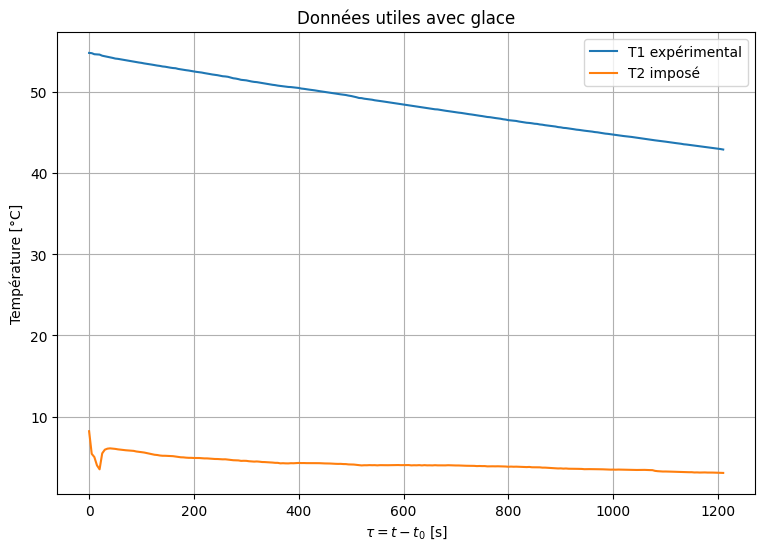

In [359]:
# ============================================================
# BLOQUE 8
# FICHIER AVEC GLACE : CHARGEMENT ET EXTRACTION DES DONNÉES
# ============================================================

print("Charge le fichier AVEC glace")

df_ice, file_ice = load_experimental_txt()


# ------------------------------------------------------------
# Extraction des colonnes
# ------------------------------------------------------------

t_ice_full = df_ice["Temps_s"].to_numpy(dtype=float)
T1_ice_full = df_ice["T1"].to_numpy(dtype=float)
T2_ice_full = df_ice["T2"].to_numpy(dtype=float)


# ------------------------------------------------------------
# Début utile : maximum de T1
# ------------------------------------------------------------

idx0_ice = int(np.argmax(T1_ice_full))

t0_ice = t_ice_full[idx0_ice]


# ------------------------------------------------------------
# Données utiles à partir du maximum de T1
# ------------------------------------------------------------

df_ice_useful = df_ice.iloc[idx0_ice:].copy().reset_index(drop=True)

df_ice_useful["tau_s"] = (
    df_ice_useful["Temps_s"]
    -
    t0_ice
)

tau_ice = df_ice_useful["tau_s"].to_numpy(dtype=float)

# T1 est la température que le modèle FEM doit reproduire
T1_ice_exp = df_ice_useful["T1"].to_numpy(dtype=float)

# T2 est la condition de Dirichlet imposée au bord froid
T2_ice_bc = df_ice_useful["T2"].to_numpy(dtype=float)


print()
print("Résultat avec glace :")
print(f"Fichier = {file_ice}")
print(f"t0 = {t0_ice:.6f} s")
print(f"T1(t0) = {T1_ice_exp[0]:.6f} °C")
print(f"T2(t0) = {T2_ice_bc[0]:.6f} °C")
print(f"Durée utile = {tau_ice[-1]:.6f} s")
print(f"Nombre de points utiles = {len(tau_ice)}")


# ------------------------------------------------------------
# Visualisation du fichier complet
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    t_ice_full,
    T1_ice_full,
    label="T1"
)

plt.plot(
    t_ice_full,
    T2_ice_full,
    label="T2"
)

plt.axvline(
    t0_ice,
    linestyle="--",
    label="Début utile : max(T1)"
)

plt.xlabel("Temps [s]")
plt.ylabel("Température [°C]")
plt.title("Fichier avec glace")
plt.grid(True)
plt.legend()
plt.show()


# ------------------------------------------------------------
# Visualisation de la partie utile
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    tau_ice,
    T1_ice_exp,
    label="T1 expérimental"
)

plt.plot(
    tau_ice,
    T2_ice_bc,
    label="T2 imposé"
)

plt.xlabel(r"$\tau = t - t_0$ [s]")
plt.ylabel("Température [°C]")
plt.title("Données utiles avec glace")
plt.grid(True)
plt.legend()
plt.show()

## Bloc 9 — Création de la fenêtre d'identification

Ce bloc sélectionne la partie droite des données expérimentales avec glace. Cette fenêtre est utilisée pour identifier `alpha`.

La sélection de cette fenêtre permet d'éviter que l'identification soit dominée par la phase initiale du signal, qui peut contenir des effets expérimentaux transitoires difficiles à modéliser.

Le masque temporel obtenu à partir de `T1` est également appliqué à `T2`. Cela garantit que la température imposée `T2_bc` correspond exactement aux mêmes instants que la température cible `T1_exp`.

Après cette extraction, le temps est à nouveau remis à zéro :

$$
\tau_{\mathrm{id}} = \tau - \tau_{\mathrm{début}}
$$

La variable `fit_start_fraction_id` est fixée à `0.0` car la fenêtre a déjà été recoupée. Les pentes sont donc calculées sur toute la fenêtre d'identification.

In [360]:
# ============================================================
# BLOQUE 9
# FENÊTRE D'IDENTIFICATION : PARTIE DROITE DES DONNÉES
# ============================================================

# On extrait la partie droite de T1.
# Le masque obtenu sera aussi appliqué à T2.

tau_ice_right, T1_ice_right, mask_ice_right = extract_right_part(
    tau_ice,
    T1_ice_exp,
    start_fraction=fit_start_fraction_ice
)

T2_ice_right = T2_ice_bc[mask_ice_right]


# ------------------------------------------------------------
# Remise du temps à zéro
# ------------------------------------------------------------
# Le nouvel instant initial correspond au début de la fenêtre droite.

tau_ice_id = tau_ice_right - tau_ice_right[0]

T1_ice_exp_id = T1_ice_right
T2_ice_bc_id = T2_ice_right


# ------------------------------------------------------------
# Très important :
# Comme la fenêtre est déjà recoupée, les pentes doivent être
# calculées sur toute cette nouvelle fenêtre.
# ------------------------------------------------------------

fit_start_fraction_id = 0.0


print("Fenêtre d'identification créée.")
print(f"Temps initial original = {tau_ice_right[0]:.6f} s")
print(f"Temps final original = {tau_ice_right[-1]:.6f} s")
print(f"Durée de la fenêtre = {tau_ice_id[-1]:.6f} s")
print(f"T1 initial pour FEM = {T1_ice_exp_id[0]:.6f} °C")
print(f"T2 initial imposé = {T2_ice_bc_id[0]:.6f} °C")
print(f"Nombre de points utilisés = {len(tau_ice_id)}")

Fenêtre d'identification créée.
Temps initial original = 610.061000 s
Temps final original = 1210.124000 s
Durée de la fenêtre = 600.063000 s
T1 initial pour FEM = 48.310000 °C
T2 initial imposé = 4.042000 °C
Nombre de points utilisés = 121


## Visualisation de la fenêtre d'identification

Cette section vérifie graphiquement quelles données sont effectivement utilisées pour identifier `alpha`.

La première figure montre la position de la fenêtre d'identification dans le signal complet. La seconde figure montre uniquement les données recoupées utilisées par le modèle.

Cette étape est importante pour contrôler que `T1_exp` et `T2_bc` sont bien synchronisées temporellement et que la fenêtre choisie correspond à la partie du signal que l'on souhaite modéliser.

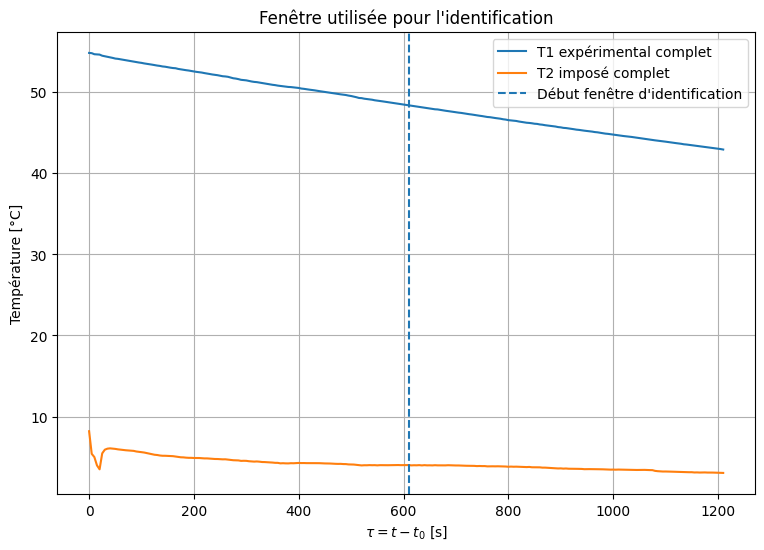

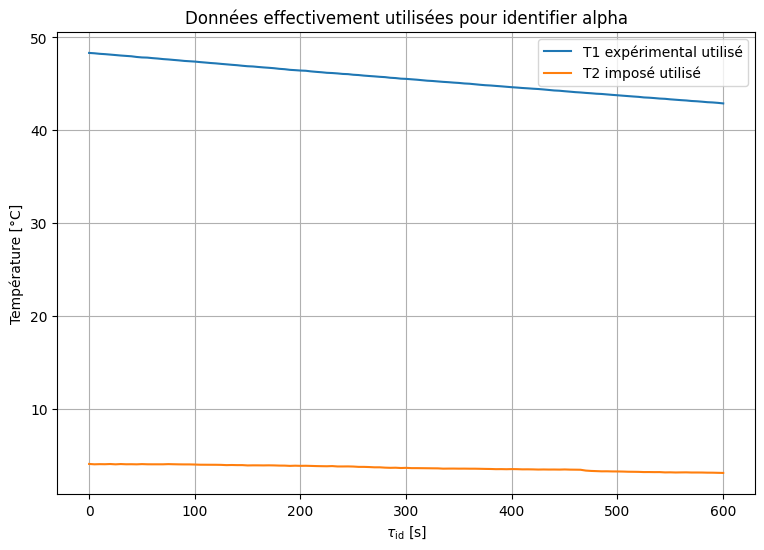

In [361]:
# ============================================================
# VISUALISATION DE LA FENÊTRE D'IDENTIFICATION
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    tau_ice,
    T1_ice_exp,
    label="T1 expérimental complet"
)

plt.plot(
    tau_ice,
    T2_ice_bc,
    label="T2 imposé complet"
)

plt.axvline(
    tau_ice_right[0],
    linestyle="--",
    label="Début fenêtre d'identification"
)

plt.xlabel(r"$\tau = t - t_0$ [s]")
plt.ylabel("Température [°C]")
plt.title("Fenêtre utilisée pour l'identification")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(9, 6))

plt.plot(
    tau_ice_id,
    T1_ice_exp_id,
    label="T1 expérimental utilisé"
)

plt.plot(
    tau_ice_id,
    T2_ice_bc_id,
    label="T2 imposé utilisé"
)

plt.xlabel(r"$\tau_{\mathrm{id}}$ [s]")
plt.ylabel("Température [°C]")
plt.title("Données effectivement utilisées pour identifier alpha")
plt.grid(True)
plt.legend()
plt.show()

## Bloc 10 — Identification de alpha sur la fenêtre droite

Ce bloc redéfinit la fonction `identify_alpha_for_n_nodes` afin de travailler uniquement avec les données de la fenêtre d'identification :

- `tau_ice_id` ;
- `T1_ice_exp_id` ;
- `T2_ice_bc_id`.

Pour chaque nombre de noeuds, le code construit un maillage uniforme entre `x = 0` et `x = L_ice`, assemble les matrices FEM, puis teste toutes les valeurs de `alpha` définies dans `alpha_values`.

Pour chaque valeur candidate de `alpha`, la fonction simule `T1_FEM(t)` et calcule sa pente. La valeur optimale `alpha_best` est celle qui minimise l'écart relatif entre la pente FEM et la pente expérimentale.

Le résultat retourné contient :

- le maillage utilisé ;
- les matrices FEM ;
- le tableau complet des erreurs pour toutes les valeurs de `alpha` ;
- la meilleure valeur de `alpha` ;
- la courbe `T1_FEM` associée ;
- les profils spatiaux sauvegardés ;
- l'information indiquant si `alpha_best` est à l'intérieur du domaine de recherche ou sur une borne.

Cette fonction remplace la version préliminaire définie plus haut.

In [362]:
# ============================================================
# BLOQUE 10
# IDENTIFICATION DE ALPHA AVEC LA FENÊTRE DROITE UNIQUEMENT
# ============================================================

def identify_alpha_for_n_nodes(N_nodes, times_to_save=None, verbose=True):
    """
    Identifie alpha pour un maillage avec N_nodes.

    Cette version utilise uniquement :
        tau_ice_id
        T1_ice_exp_id
        T2_ice_bc_id

    Donc tout le calcul de alpha se fait sur la fenêtre droite.
    """

    required_variables = [
        "tau_ice_id",
        "T1_ice_exp_id",
        "T2_ice_bc_id",
        "fit_start_fraction_id",
        "s_loss_no_ice",
        "L_ice",
        "alpha_values"
    ]

    for variable_name in required_variables:
        if variable_name not in globals():
            raise NameError(
                f"La variable {variable_name} n'existe pas encore. "
                "Il faut exécuter les blocs précédents."
            )

    if N_nodes < 2:
        raise ValueError("Il faut au moins 2 noeuds.")

    N_elements = N_nodes - 1

    x_nodes = np.linspace(
        0.0,
        L_ice,
        N_nodes
    )

    M, K, F = assemble_fem_1d_p1(
        x_nodes=x_nodes,
        s_loss=s_loss_no_ice
    )

    slope_T1_exp = linear_slope(
        tau_ice_id,
        T1_ice_exp_id,
        start_fraction=fit_start_fraction_id
    )

    rows = []

    for alpha_value in alpha_values:

        T1_fem_alpha, _ = simulate_T1_for_alpha_mesh(
            alpha=alpha_value,
            tau=tau_ice_id,
            T1_exp=T1_ice_exp_id,
            T2_bc=T2_ice_bc_id,
            x_nodes=x_nodes,
            M=M,
            K=K,
            F=F,
            times_to_save=None
        )

        slope_T1_fem = linear_slope(
            tau_ice_id,
            T1_fem_alpha,
            start_fraction=fit_start_fraction_id
        )

        abs_error = abs(slope_T1_fem - slope_T1_exp)

        rel_error = abs_error / max(
            abs(slope_T1_exp),
            1.0e-15
        )

        rows.append({
            "N_nodes": N_nodes,
            "N_elements": N_elements,
            "alpha": alpha_value,
            "slope_T1_exp": slope_T1_exp,
            "slope_T1_fem": slope_T1_fem,
            "abs_slope_error": abs_error,
            "relative_slope_error": rel_error
        })

    df_alpha = pd.DataFrame(rows)

    idx_best = df_alpha["relative_slope_error"].idxmin()

    best_row = df_alpha.loc[idx_best].copy()

    alpha_best = best_row["alpha"]

    T1_fem_best, saved_profiles = simulate_T1_for_alpha_mesh(
        alpha=alpha_best,
        tau=tau_ice_id,
        T1_exp=T1_ice_exp_id,
        T2_bc=T2_ice_bc_id,
        x_nodes=x_nodes,
        M=M,
        K=K,
        F=F,
        times_to_save=times_to_save
    )

    if alpha_best == alpha_values[0]:
        boundary_status = "lower_bound"
    elif alpha_best == alpha_values[-1]:
        boundary_status = "upper_bound"
    else:
        boundary_status = "inside"

    if verbose:
        print()
        print("Résultat pour le maillage :")
        print(f"N_nodes = {N_nodes}")
        print(f"N_elements = {N_elements}")
        print(f"alpha_best = {alpha_best:.6e} m²/s")
        print(f"pente T1 exp = {best_row['slope_T1_exp']:.6e} °C/s")
        print(f"pente T1 FEM = {best_row['slope_T1_fem']:.6e} °C/s")
        print(f"erreur absolue de pente = {best_row['abs_slope_error']:.6e} °C/s")
        print(f"écart relatif de pente = {100.0 * best_row['relative_slope_error']:.6f} %")
        print(f"position dans l'intervalle alpha = {boundary_status}")

    return {
        "N_nodes": N_nodes,
        "N_elements": N_elements,
        "x_nodes": x_nodes,
        "M": M,
        "K": K,
        "F": F,
        "df_alpha": df_alpha,
        "best_row": best_row,
        "alpha_best": alpha_best,
        "T1_fem_best": T1_fem_best,
        "saved_profiles": saved_profiles,
        "boundary_status": boundary_status
    }


print("Fonction d'identification de alpha redéfinie avec la fenêtre droite.")

Fonction d'identification de alpha redéfinie avec la fenêtre droite.


## Bloc 11 — Étude de convergence en maillage

Ce bloc exécute l'identification de `alpha` pour plusieurs maillages.

Les nombres de noeuds testés sont :

$$
2,\ 3,\ 5,\ 9,\ 17,\ 33,\ 65
$$

Pour chaque maillage, la fonction `identify_alpha_for_n_nodes` est appelée. Les résultats sont stockés dans deux objets :

- `mesh_results`, qui conserve les résultats complets de chaque simulation ;
- `df_mesh_convergence`, qui résume les grandeurs principales dans un tableau.

Le tableau final permet de comparer la valeur identifiée de `alpha`, son rapport à la valeur bibliographique de l'acier, les pentes expérimentales et numériques, ainsi que l'erreur relative de pente.

In [363]:
# ============================================================
# BLOQUE 11
# EXECUTION DE L'IDENTIFICATION POUR PLUSIEURS MAILLAGES
# ============================================================

N_nodes_values = [
    2,
    3,
    5,
    9,
    17,
    33,
    65
]

times_to_save_id = [
    tau_ice_id[0],
    0.25 * tau_ice_id[-1],
    0.50 * tau_ice_id[-1],
    tau_ice_id[-1]
]

mesh_results = []
summary_rows = []

for N_nodes in N_nodes_values:

    result = identify_alpha_for_n_nodes(
        N_nodes=N_nodes,
        times_to_save=times_to_save_id,
        verbose=True
    )

    mesh_results.append(result)

    best_row = result["best_row"]

    summary_rows.append({
        "N_nodes": result["N_nodes"],
        "N_elements": result["N_elements"],
        "alpha_best": result["alpha_best"],
        "alpha_best_over_alpha_steel": result["alpha_best"] / alpha_steel_ref,
        "slope_T1_exp": best_row["slope_T1_exp"],
        "slope_T1_fem": best_row["slope_T1_fem"],
        "abs_slope_error": best_row["abs_slope_error"],
        "relative_slope_error_percent": 100.0 * best_row["relative_slope_error"],
        "boundary_status": result["boundary_status"]
    })

df_mesh_convergence = pd.DataFrame(summary_rows)

display(df_mesh_convergence)


Résultat pour le maillage :
N_nodes = 2
N_elements = 1
alpha_best = 2.525820e-07 m²/s
pente T1 exp = -9.041085e-03 °C/s
pente T1 FEM = -9.047625e-03 °C/s
erreur absolue de pente = 6.540608e-06 °C/s
écart relatif de pente = 0.072343 %
position dans l'intervalle alpha = inside

Résultat pour le maillage :
N_nodes = 3
N_elements = 2
alpha_best = 1.318621e-07 m²/s
pente T1 exp = -9.041085e-03 °C/s
pente T1 FEM = -9.025247e-03 °C/s
erreur absolue de pente = 1.583780e-05 °C/s
écart relatif de pente = 0.175176 %
position dans l'intervalle alpha = inside

Résultat pour le maillage :
N_nodes = 5
N_elements = 4
alpha_best = 8.015007e-08 m²/s
pente T1 exp = -9.041085e-03 °C/s
pente T1 FEM = -9.036080e-03 °C/s
erreur absolue de pente = 5.004596e-06 °C/s
écart relatif de pente = 0.055354 %
position dans l'intervalle alpha = inside

Résultat pour le maillage :
N_nodes = 9
N_elements = 8
alpha_best = 6.650018e-08 m²/s
pente T1 exp = -9.041085e-03 °C/s
pente T1 FEM = -9.032558e-03 °C/s
erreur absolue

,N_nodes,N_elements,alpha_best,alpha_best_over_alpha_steel,slope_T1_exp,slope_T1_fem,abs_slope_error,relative_slope_error_percent,boundary_status
0,2,1,2.525820e-07,0.921015,-0.009041,-0.009048,0.000007,0.072343,inside
1,3,2,1.318621e-07,0.480822,-0.009041,-0.009025,0.000016,0.175176,inside
2,5,4,8.015007e-08,0.292259,-0.009041,-0.009036,0.000005,0.055354,inside
3,9,8,6.650018e-08,0.242486,-0.009041,-0.009033,0.000009,0.094317,inside
4,17,16,7.427982e-08,0.270854,-0.009041,-0.009035,0.000006,0.071351,inside
5,33,32,7.850456e-08,0.286259,-0.009041,-0.009031,0.000010,0.107827,inside
6,65,64,8.015007e-08,0.292259,-0.009041,-0.009049,0.000008,0.083007,inside


## Bloc 12 — Graphiques de convergence

Ce bloc visualise la convergence de l'identification lorsque le nombre de noeuds augmente.

Le premier graphique montre la valeur identifiée de la diffusivité thermique `alpha_best` en fonction du nombre de noeuds. Une ligne horizontale indique la diffusivité thermique bibliographique de l'acier, utilisée comme référence.

Le deuxième graphique montre le rapport :

$$
\frac{\alpha^\star}{\alpha_{\mathrm{acier}}}
$$

Cela permet de comparer directement la diffusivité identifiée à une valeur physique de référence.

Le troisième graphique montre l'erreur relative de pente entre `T1_FEM` et `T1_exp`. Une diminution ou une stabilisation de cette erreur avec le raffinement du maillage indique une meilleure cohérence numérique de l'identification.

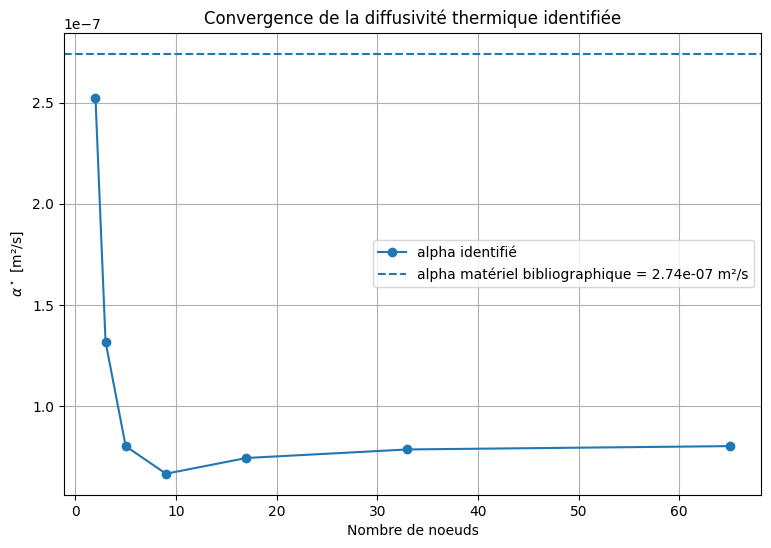

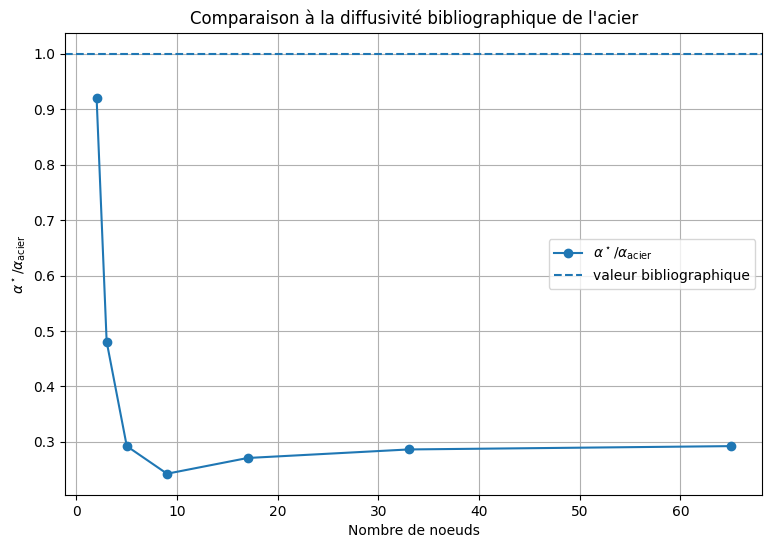

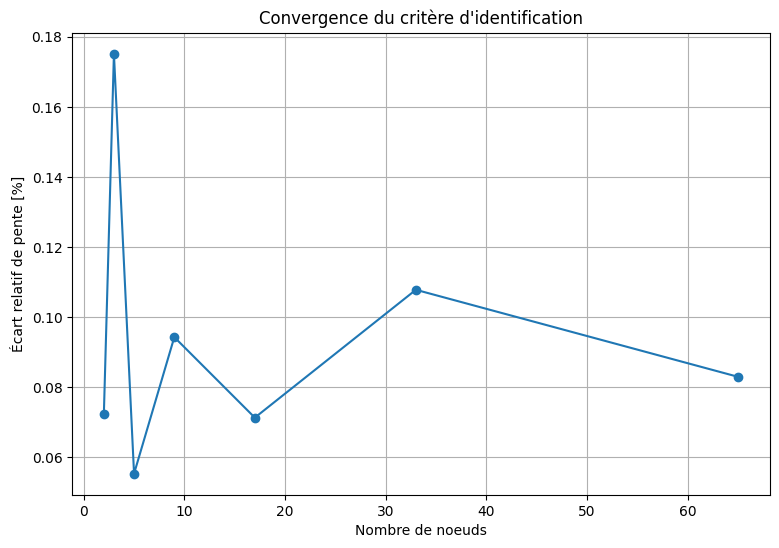

In [364]:
# ============================================================
# BLOQUE 12
# GRAPHIQUES DE CONVERGENCE DE ALPHA
# ============================================================

# ------------------------------------------------------------
# Graphique 1 : alpha identifié en fonction du nombre de noeuds
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    df_mesh_convergence["N_nodes"],
    df_mesh_convergence["alpha_best"],
    marker="o",
    label="alpha identifié"
)

plt.axhline(
    alpha_steel_ref,
    linestyle="--",
    label=f"alpha matériel bibliographique = {alpha_steel_ref:.2e} m²/s"
)

plt.xlabel("Nombre de noeuds")
plt.ylabel(r"$\alpha^\star$ [m²/s]")
plt.title("Convergence de la diffusivité thermique identifiée")
plt.grid(True)
plt.legend()
plt.show()


# ------------------------------------------------------------
# Graphique 2 : ratio alpha identifié / alpha acier
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    df_mesh_convergence["N_nodes"],
    df_mesh_convergence["alpha_best_over_alpha_steel"],
    marker="o",
    label=r"$\alpha^\star / \alpha_{\mathrm{acier}}$"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="valeur bibliographique"
)

plt.xlabel("Nombre de noeuds")
plt.ylabel(r"$\alpha^\star / \alpha_{\mathrm{acier}}$")
plt.title("Comparaison à la diffusivité bibliographique de l'acier")
plt.grid(True)
plt.legend()
plt.show()


# ------------------------------------------------------------
# Graphique 3 : erreur relative de pente
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    df_mesh_convergence["N_nodes"],
    df_mesh_convergence["relative_slope_error_percent"],
    marker="o"
)

plt.xlabel("Nombre de noeuds")
plt.ylabel("Écart relatif de pente [%]")
plt.title("Convergence du critère d'identification")
plt.grid(True)
plt.show()

## Bloc 13 — Comparaison temporelle entre T1 expérimental et T1 FEM

Ce bloc compare directement les courbes temporelles obtenues avec les différents maillages.

La courbe `T2 imposé` correspond à la condition de Dirichlet appliquée au bord froid. La courbe `T1 expérimental` est la mesure que le modèle cherche à reproduire. Les autres courbes correspondent aux températures `T1_FEM` simulées pour chaque maillage avec la valeur optimale de `alpha`.

Cette figure est essentielle car elle permet de vérifier visuellement si le modèle reproduit non seulement la pente globale de refroidissement, mais aussi la forme de la courbe expérimentale.

La correction de la condition initiale est particulièrement visible dans cette comparaison : avec un profil initial linéaire entre `T1(0)` et `T2(0)`, les maillages raffinés ne créent plus de réserve thermique artificielle dans le domaine.

fem 2.141056000869419
exp 2.597999999999999


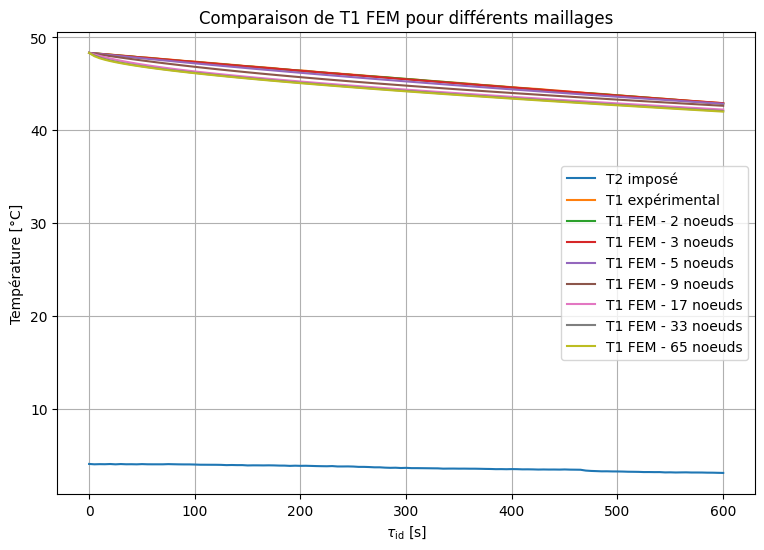

In [365]:
# ============================================================
# BLOQUE 13
# COMPARAISON TEMPORELLE ENTRE T1 EXPERIMENTAL ET T1 FEM
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    tau_ice_id,
    T2_ice_bc_id,
    label="T2 imposé"
)

plt.plot(
    tau_ice_id,
    T1_ice_exp_id,
    label="T1 expérimental"
)

for result in mesh_results:

    plt.plot(
        tau_ice_id,
        result["T1_fem_best"],
        label=f"T1 FEM - {result['N_nodes']} noeuds"
    )

print("fem", result["T1_fem_best"][-int(len(result["T1_fem_best"])/2)]-result["T1_fem_best"][-1])
print("exp", T1_ice_exp_id[-int(len(T1_ice_exp_id)/2)]-T1_ice_exp_id[-1])



plt.xlabel(r"$\tau_{\mathrm{id}}$ [s]")
plt.ylabel("Température [°C]")
plt.title("Comparaison de T1 FEM pour différents maillages")
plt.grid(True)
plt.legend()
plt.show()

## Bloc 14 — Profils spatiaux de température

Ce bloc trace les profils spatiaux de température `T(x,t)` au dernier instant de la fenêtre d'identification.

Ces profils permettent de visualiser la distribution de température dans le domaine 1D entre les deux capteurs. Le dernier noeud correspond à la température imposée `T2(t)`, tandis que le premier noeud correspond à la température calculée `T1_FEM(t)`.

La comparaison des profils pour plusieurs maillages permet de vérifier que le champ spatial devient cohérent lorsque le maillage est raffiné.

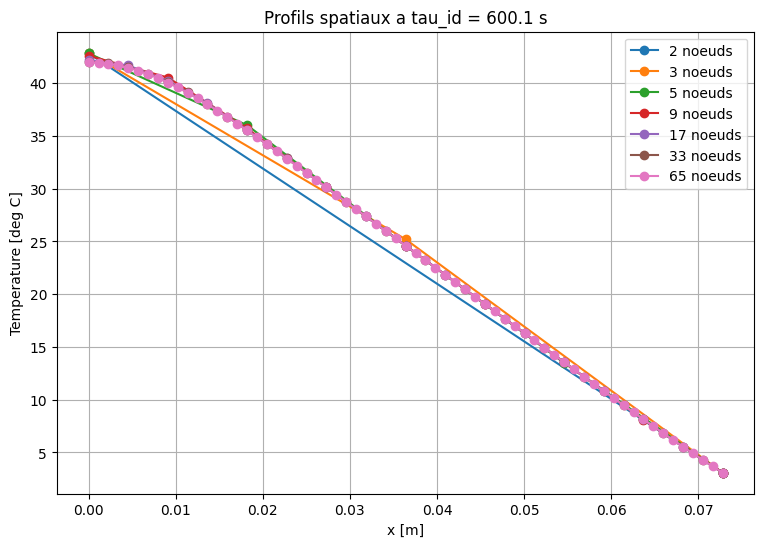

In [366]:
# ============================================================
# BLOQUE 14
# PROFILS SPATIAUX T(x,t) AU DERNIER INSTANT
# ============================================================

target_time_id = tau_ice_id[-1]

plt.figure(figsize=(9, 6))

for result in mesh_results:

    saved_profiles = result["saved_profiles"]

    if len(saved_profiles) == 0:
        raise ValueError(
            "Aucun profil spatial n'a ete sauvegarde. "
            "Il faut executer le BLOQUE 11 avec times_to_save_id."
        )

    saved_indices = list(saved_profiles.keys())

    saved_times = np.array([
        tau_ice_id[idx]
        for idx in saved_indices
    ])

    idx_closest = int(
        np.argmin(
            np.abs(saved_times - target_time_id)
        )
    )

    saved_index = saved_indices[idx_closest]

    T_profile = saved_profiles[saved_index]

    plt.plot(
        result["x_nodes"],
        T_profile,
        marker="o",
        label=f"{result['N_nodes']} noeuds"
    )

plt.xlabel("x [m]")
plt.ylabel("Temperature [deg C]")
plt.title(f"Profils spatiaux a tau_id = {target_time_id:.1f} s")
plt.grid(True)
plt.legend()
plt.show()

In [367]:
for result in mesh_results:

    print((result["T1_fem_best"][int(len(result["T1_fem_best"])/2)]-result["T1_fem_best"][-1])/700, \
          (T1_ice_exp_id[int(len(result["T1_fem_best"])/2)]-T1_ice_exp_id[-1])/700)

0.0037921114431470316 0.0037757142857142868
0.003673817225181283 0.0037757142857142868
0.0034337295944307806 0.0037757142857142868
0.003103829019398613 0.0037757142857142868
0.0030699834169838677 0.0037757142857142868
0.0031017516678111335 0.0037757142857142868
0.003117360840839061 0.0037757142857142868


## Conclusion

Ce notebook met en place une méthode d'identification de la diffusivité thermique effective `alpha` à partir d'un modèle éléments finis transitoire 1D.

La température `T2(t)` est imposée comme condition de Dirichlet variable dans le temps, tandis que la température `T1(t)` est calculée par le modèle puis comparée aux données expérimentales.

Une étape importante de la méthode est la correction de la condition initiale. Au lieu d'initialiser tous les noeuds libres avec `T1(0)`, le modèle utilise un profil initial linéaire entre `T1(0)` et `T2(0)`. Cette approche garantit que le champ thermique initial est compatible avec les deux mesures expérimentales et évite l'introduction d'une réserve thermique artificielle dans le domaine.

L'étude de convergence en maillage permet ensuite d'évaluer la stabilité de la valeur identifiée de `alpha` lorsque le nombre de noeuds augmente.